# Exploratory Data Analysis on Retail Sales Data

## Objective

The objective of this project is to perform a thorough Exploratory Data Analysis (EDA) on a retail sales dataset to uncover sales patterns, customer behaviour trends, product performance, and actionable business insights.

## Tools and Technologies

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Analysis Objectives

This project includes:

1. Initial data inspection and data quality assessment.
2. Descriptive statistical analysis.
3. Monthly and quarterly sales trend analysis.
4. Customer demographic analysis based on age and gender.
5. Product and category performance analysis.
6. Correlation analysis between numerical variables.
7. Additional visualisation to identify a non-obvious business insight.
8. Actionable business recommendations based on the findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Set chart style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset

df = pd.read_csv("retail_sales_dataset.csv")

# Display the first five rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Initial Dataset Inspection

In [3]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

DATASET SHAPE
Number of Rows: 1000
Number of Columns: 9


In [4]:
# Display Column Names
print("DATASET COLUMNS")

for column in df.columns:
    print(column)

DATASET COLUMNS
Transaction ID
Date
Customer ID
Gender
Age
Product Category
Quantity
Price per Unit
Total Amount


In [5]:
# Check Data Types

print(" Data Types")
df.dtypes

 Data Types


Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [6]:
# Detailed Dataset Information

print("DATASET INFORMATION")

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [7]:
# Missing Values Check
print("MISSING VALUES")

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df)) * 100
})

missing_summary

MISSING VALUES


,Missing Values,Percentage (%)
Transaction ID,0,0.0
Date,0,0.0
Customer ID,0,0.0
Gender,0,0.0
Age,0,0.0
Product Category,0,0.0
Quantity,0,0.0
Price per Unit,0,0.0
Total Amount,0,0.0


In [8]:
# Duplicate Values Check
duplicate_rows = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicate_rows}")

Number of Duplicate Rows: 0


## Initial Data Inspection – Observation

The initial inspection was conducted to understand the overall structure and quality of the retail sales dataset. The dataset shape, column names, data types, missing values, and duplicate records were examined before beginning the detailed analysis.

Any missing values, duplicate records, or incorrect data types identified during this stage should be considered when interpreting the results of the analysis.

In [9]:
# COLUMN CONFIGURATION

DATE_COLUMN = "Date"
SALES_COLUMN = "Sales"
AGE_COLUMN = "Age"
GENDER_COLUMN = "Gender"
PRODUCT_COLUMN = "Product"
CATEGORY_COLUMN = "Product Category"
QUANTITY_COLUMN = "Quantity"

In [10]:
# Convert the date column to datetime format

df[DATE_COLUMN] = pd.to_datetime(
    df[DATE_COLUMN],
    errors="coerce"
)

print("Date column converted successfully.")

# Check for invalid dates
invalid_dates = df[DATE_COLUMN].isnull().sum()

print(f"Invalid or missing dates: {invalid_dates}")

Date column converted successfully.
Invalid or missing dates: 0


In [11]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Numerical Columns:")

for column in numerical_columns:
    print("-", column)

Numerical Columns:
- Transaction ID
- Age
- Quantity
- Price per Unit
- Total Amount


In [12]:
numerical_columns = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
['Age', 'Quantity', 'Price per Unit', 'Total Amount']


## Descriptive Statistics

In [13]:
descriptive_statistics = pd.DataFrame({
    
    "Mean": df[numerical_columns].mean(),
    
    "Median": df[numerical_columns].median(),
    
    "Mode": df[numerical_columns].mode().iloc[0],
    
    "Standard Deviation": df[numerical_columns].std()
})

descriptive_statistics

,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [14]:
df[numerical_columns].describe()

,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


## Descriptive Statistics – Observation

The descriptive statistical analysis provides an overview of the central tendency and variability of the numerical variables in the dataset.

The mean and median help identify the typical values of each variable, while the mode identifies the most frequently occurring value. The standard deviation indicates the degree of variation within each numerical variable.

Any substantial differences between the mean and median may suggest that the data is skewed or contains extreme values.

In [15]:
# Create Month column

df["Month"] = df[DATE_COLUMN].dt.to_period("M")

# Create Quarter column

df["Quarter"] = df[DATE_COLUMN].dt.to_period("Q")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,2023Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,2023Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,2023Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2023Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2023Q2


In [16]:
# Convert Date column to datetime
df[DATE_COLUMN] = pd.to_datetime(
    df[DATE_COLUMN],
    errors="coerce"
)

# Create Month column
df["Month"] = df[DATE_COLUMN].dt.to_period("M")

# Create Quarter column
df["Quarter"] = df[DATE_COLUMN].dt.to_period("Q")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,2023Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,2023Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,2023Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2023Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2023Q2


In [17]:
print(df.columns.tolist())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Month', 'Quarter']


In [18]:
print(SALES_COLUMN)

Sales


In [19]:
DATE_COLUMN = "Date"
SALES_COLUMN = "Total Amount"
AGE_COLUMN = "Age"
GENDER_COLUMN = "Gender"
CATEGORY_COLUMN = "Product Category"
QUANTITY_COLUMN = "Quantity"

print("Sales column:", SALES_COLUMN)

Sales column: Total Amount


In [20]:
print(df.columns.tolist())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'Month', 'Quarter']


In [21]:
monthly_sales = (
    df.groupby("Month")[SALES_COLUMN]
    .sum()
    .reset_index()
)

monthly_sales["Month"] = monthly_sales["Month"].astype(str)

monthly_sales

,Month,Total Amount
0,2023-01,35450
1,2023-02,44060
2,2023-03,28990
3,2023-04,33870
4,2023-05,53150
5,2023-06,36715
6,2023-07,35465
7,2023-08,36960
8,2023-09,23620
9,2023-10,46580


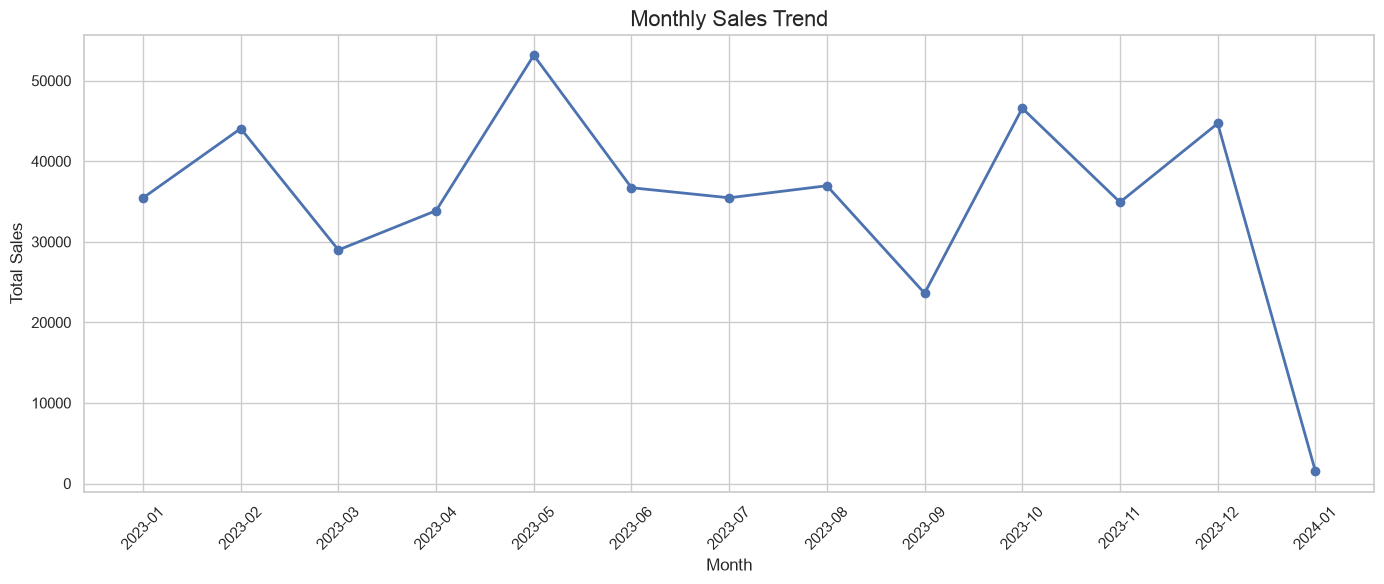

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales[SALES_COLUMN],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=16)

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Monthly Sales Trend – Observation

Monthly sales fluctuated considerably throughout the dataset. May 2023 recorded the highest monthly sales at 53,150, while September 2023 recorded the lowest sales among the complete months at 23,620.

The variation in monthly sales suggests changing customer demand throughout the year. The business should investigate the factors contributing to strong performance in May and consider targeted promotions during lower-performing months such as September.

In [23]:
quarterly_sales = (
    df.groupby("Quarter")[SALES_COLUMN]
    .sum()
    .reset_index()
)

quarterly_sales["Quarter"] = quarterly_sales["Quarter"].astype(str)

quarterly_sales

,Quarter,Total Amount
0,2023Q1,108500
1,2023Q2,123735
2,2023Q3,96045
3,2023Q4,126190
4,2024Q1,1530


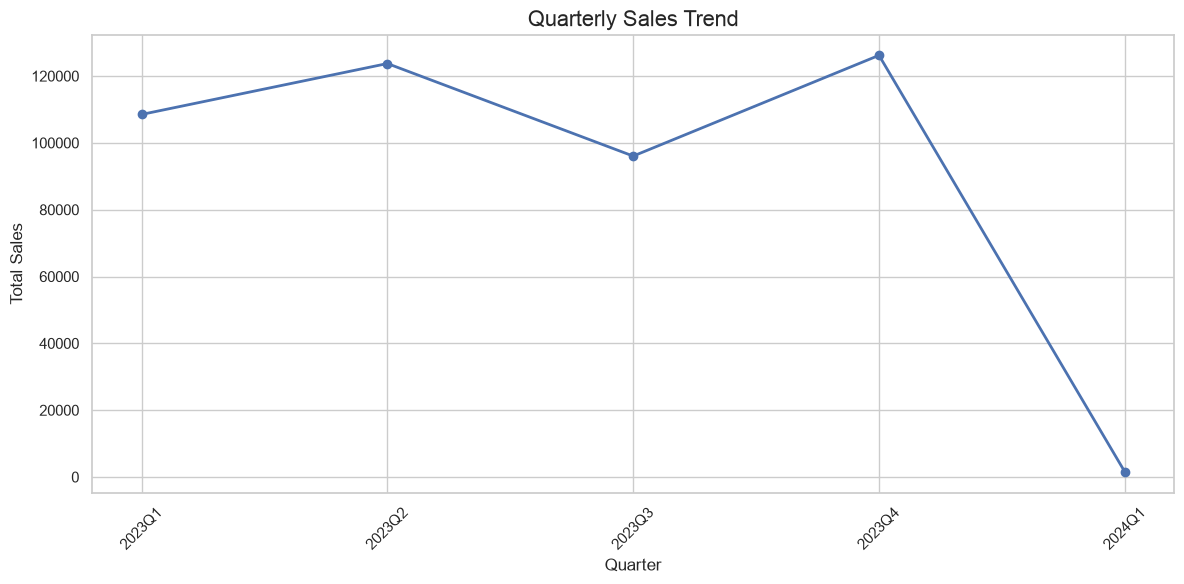

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_sales["Quarter"],
    quarterly_sales[SALES_COLUMN],
    marker="o",
    linewidth=2
)

plt.title("Quarterly Sales Trend", fontsize=16)

plt.xlabel("Quarter")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Quarterly Sales Trend – Observation

Among the complete quarters, the fourth quarter of 2023 generated the highest sales revenue at 126,190. The third quarter of 2023 recorded the lowest revenue at 96,045.

The strong performance in the fourth quarter may indicate increased customer demand or seasonal purchasing behaviour. The business should investigate successful sales activities during this period and consider applying similar strategies during lower-performing quarters.

The 2024 Q1 result should be interpreted carefully because the dataset contains only partial data for January 2024.

## Customer Age Distribution – Observation

The customer age distribution illustrates the spread of customers across different age ranges. The analysis helps identify the demographic groups that are most frequently represented in retail transactions.

Understanding the age distribution can support customer segmentation and help the business develop marketing strategies that are appropriate for its major customer groups.

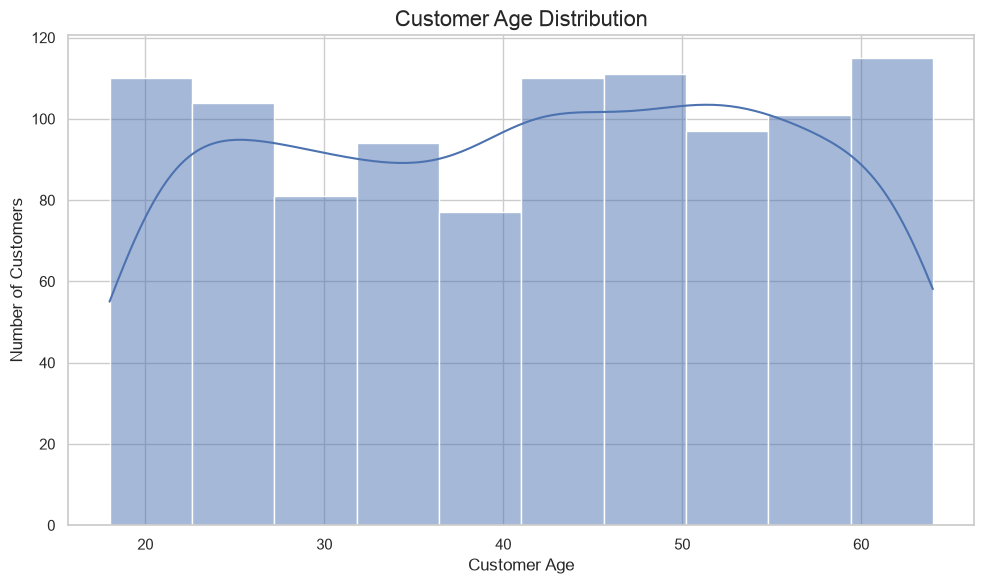

In [26]:
# customer age distributer
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x=AGE_COLUMN,
    bins=10,
    kde=True
)

plt.title("Customer Age Distribution", fontsize=16)

plt.xlabel("Customer Age")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

## Create Customer Age Groups

In [27]:
# Define age groups

bins = [0, 20, 30, 40, 50, 60, 100]

labels = [
    "Under 20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "60+"
]

df["Age Group"] = pd.cut(
    df[AGE_COLUMN],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["Age Group", AGE_COLUMN]].head()

,Age Group,Age
0,31-40,34
1,21-30,26
2,41-50,50
3,31-40,37
4,21-30,30


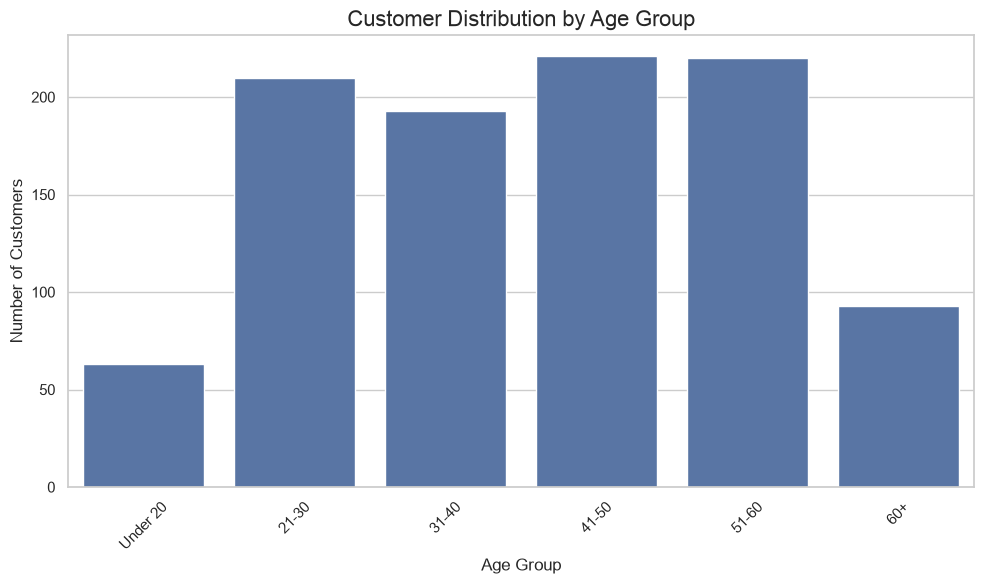

In [28]:
# Age Group Distribution
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Age Group"
)

plt.title(
    "Customer Distribution by Age Group",
    fontsize=16
)

plt.xlabel("Age Group")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Customer Age Analysis – Observation

The age distribution analysis identifies the demographic groups that represent the largest proportion of customers.

The results can help the business understand its primary customer segments and develop targeted marketing strategies. However, the largest customer group may not necessarily generate the highest revenue, making it important to compare customer demographics with purchasing behaviour.

In [29]:
# Gender Breakdown
gender_distribution = df[GENDER_COLUMN].value_counts()

gender_distribution

Gender
Female    510
Male      490
Name: count, dtype: int64

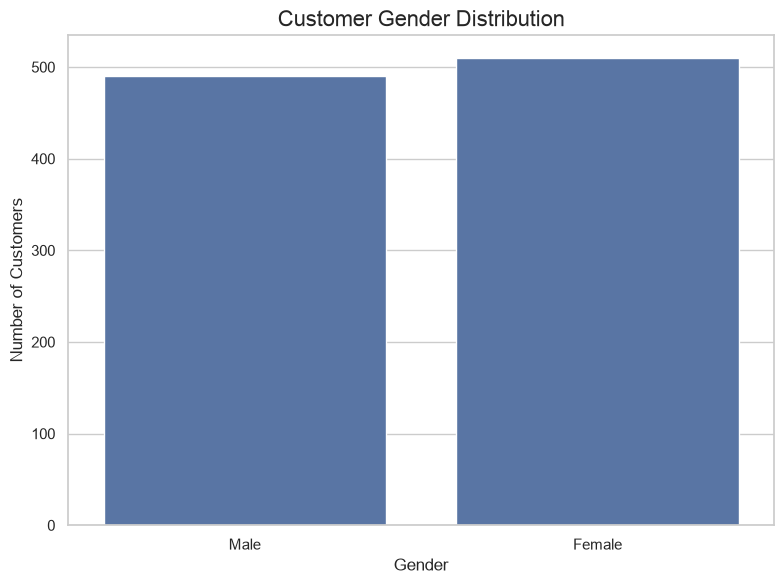

In [30]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x=GENDER_COLUMN
)

plt.title(
    "Customer Gender Distribution",
    fontsize=16
)

plt.xlabel("Gender")

plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()

## Gender Distribution – Observation

The dataset contains a relatively balanced distribution of male and female customers. Female customers account for 510 transactions, while male customers account for 490 transactions.

This relatively balanced customer distribution suggests that the business serves both gender groups. Therefore, future marketing strategies should not focus exclusively on one gender without further evidence of differences in purchasing value or product preferences.

In [31]:
top_categories = (
    df.groupby(CATEGORY_COLUMN)[QUANTITY_COLUMN]
    .sum()
    .sort_values(ascending=False)
)

top_categories

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

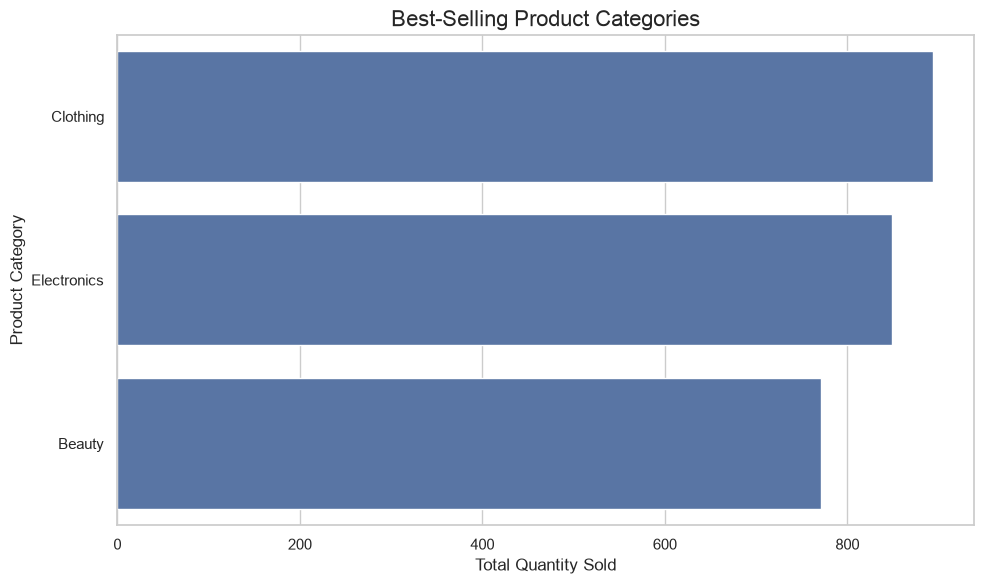

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Best-Selling Product Categories", fontsize=16)
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

## Dataset Limitation

The dataset does not contain individual product names. Instead, it provides three broad product categories: Clothing, Electronics, and Beauty.

Therefore, the product performance analysis focuses on identifying the best-selling product categories based on total quantity sold rather than presenting a top 10 list of individual products.

## Best-Selling Product Categories – Observation

The analysis identifies the product categories with the highest sales volume based on the total quantity sold.

The category with the highest quantity sold represents the strongest area of customer demand. This information can support inventory planning and marketing decisions by helping the business prioritise high-demand product categories.

## Revenue by Product Category

In [33]:
category_revenue = (
    df.groupby(CATEGORY_COLUMN)[SALES_COLUMN]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

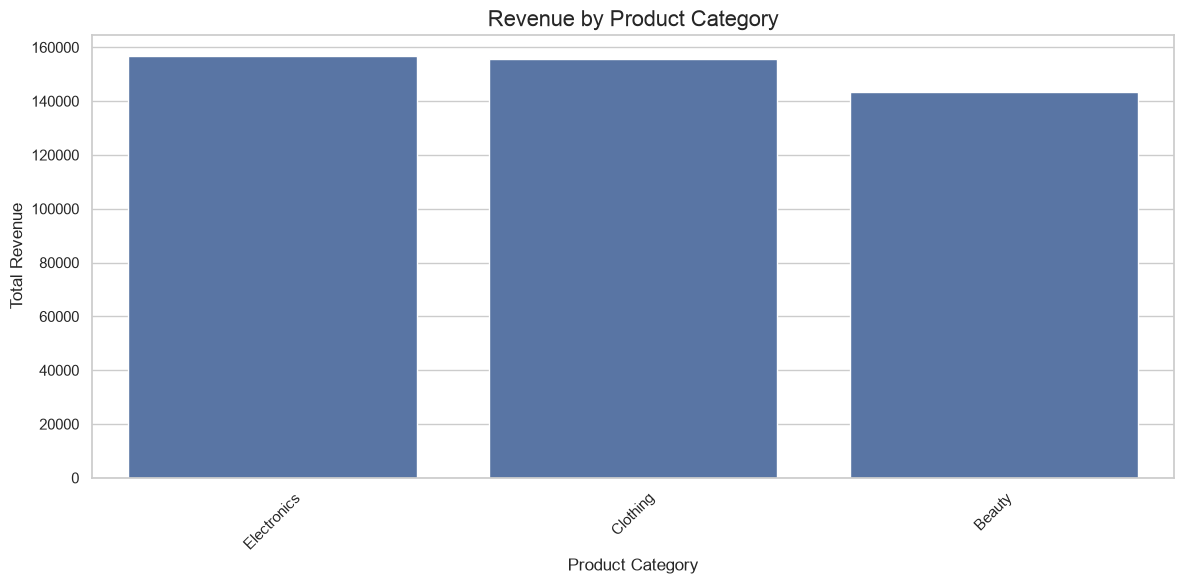

In [34]:
# Revenue by Product Category Bar Chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title(
    "Revenue by Product Category",
    fontsize=16
)

plt.xlabel("Product Category")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Product Category Revenue – Observation

Electronics generated the highest total revenue of 156,905, followed closely by Clothing with 155,580. Beauty generated the lowest total revenue at 143,515.

Although Clothing recorded the highest quantity sold, Electronics generated the highest revenue. This indicates that sales volume alone does not necessarily determine revenue performance, as higher-priced products can generate greater revenue despite lower sales quantities.

In [35]:
# Correlation Matrix
numerical_data = df.select_dtypes(
    include=np.number
)

correlation_matrix = numerical_data.corr()

correlation_matrix

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


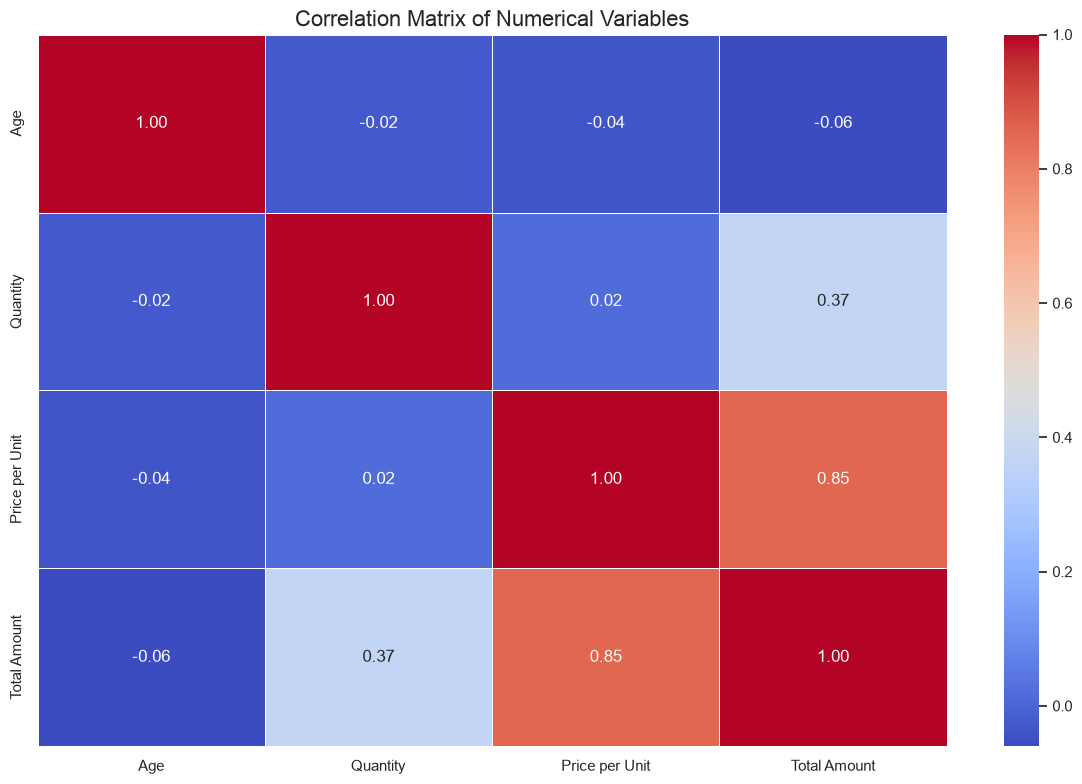

In [40]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Variables",
    fontsize=16
)

plt.tight_layout()

plt.show()

## Correlation Analysis – Observation

The correlation analysis reveals a strong positive relationship between Price per Unit and Total Amount, with a correlation coefficient of approximately 0.85.

Quantity also has a moderate positive relationship with Total Amount, with a correlation of approximately 0.37. This suggests that product pricing has a stronger association with transaction revenue than quantity alone.

Customer age shows a very weak relationship with Total Amount, indicating that age alone may not be a strong predictor of individual transaction value.

In [37]:
# average sales by age group 
age_group_sales = (
    df.groupby(
        "Age Group",
        observed=True
    )[SALES_COLUMN]
    .mean()
    .sort_values(ascending=False)
)

age_group_sales

Age Group
Under 20    551.269841
31-40       497.150259
21-30       467.690476
51-60       454.931818
41-50       424.411765
60+         357.258065
Name: Total Amount, dtype: float64

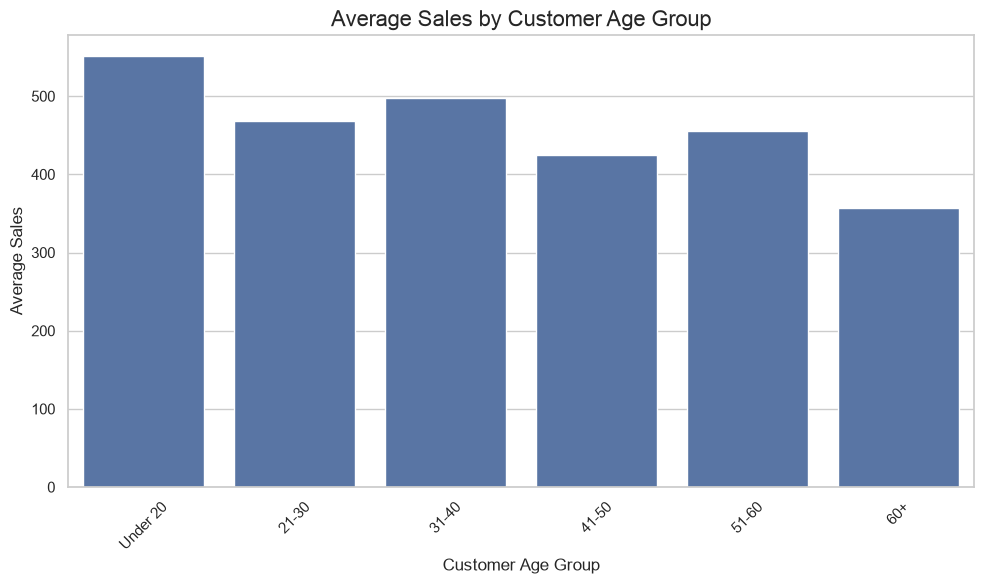

In [38]:
# average sales by age group chart
plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_group_sales.index,
    y=age_group_sales.values
)

plt.title(
    "Average Sales by Customer Age Group",
    fontsize=16
)

plt.xlabel("Customer Age Group")

plt.ylabel("Average Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Additional Business Insight – Average Sales by Age Group

The analysis reveals that customers under the age of 20 generated the highest average transaction value at approximately 551.27. In contrast, customers aged over 60 recorded the lowest average transaction value at approximately 357.26.

This is a non-obvious insight because the age group with the highest average spending may not necessarily be the largest customer group. The results suggest that younger customers could represent a valuable customer segment for targeted promotions and personalised marketing strategies.

# Conclusion and Business Recommendations

## Conclusion

The exploratory data analysis identified important patterns in retail sales performance, customer demographics, product category demand, and customer purchasing behaviour.

The analysis showed that sales performance varied significantly across different months and quarters. The fourth quarter of 2023 generated the highest quarterly revenue, while May 2023 was the strongest individual month.

Product category analysis revealed that Clothing had the highest sales volume, while Electronics generated the highest revenue. This demonstrates that a higher quantity of products sold does not always result in the highest revenue.

The additional customer demographic analysis revealed that customers under the age of 20 generated the highest average transaction value. This demonstrates the importance of analysing customer value rather than focusing only on the number of customers within each demographic group.

## Business Recommendations

### 1. Prioritise High-Revenue Product Categories

The business should prioritise Electronics in inventory planning and marketing strategies because it generated the highest total revenue. Further analysis should identify the factors contributing to its strong financial performance.

### 2. Improve Inventory Planning for High-Demand Categories

Clothing recorded the highest quantity sold. The business should ensure sufficient inventory availability for this category to minimise stock shortages and avoid potential lost sales.

### 3. Develop Targeted Marketing for High-Value Customer Segments

Customers under the age of 20 recorded the highest average transaction value. The business should investigate this customer segment further and develop targeted promotions or personalised marketing campaigns to increase customer engagement and revenue.

### 4. Use Seasonal Trends for Sales Planning

The strong sales performance during May and the fourth quarter of 2023 should be investigated to identify successful factors or seasonal demand patterns. These insights can be used to improve promotional planning during lower-performing periods.

### 5. Focus on Revenue as Well as Sales Volume

The difference between Clothing and Electronics demonstrates that sales quantity alone does not provide a complete measure of business performance. The company should evaluate both sales volume and revenue when making product and inventory decisions.